# Chapter 8. 합성곱 신경망 (CNN; Convolutional neural network)
- 합성곱 신경망 개념과 구성요소
- 합성곱 층의 필터와 활성화 출력을 시각화 해서 합성곱 신경망이 학습한 내용을 고찰

# 08-1 합성곱 신경망의 구성 요소
- 합성곱 Convolution : 함수 여러개를 더하고 곱하는 등 연산을 하여 새로운 함수를 만들어냄
- 1개 이상의 합성곱 층을 쓴 인공 신경망을 합성곱 신경망이라고 지칭
- 사용 이유 : 파라미터 수를 획기적으로 줄일 수 있음

![alt text](appendix/ch8/image-4.png)
[참고자료: 오승상 교수님](https://sites.google.com/view/seungsangoh/youtube-%EA%B0%95%EC%9D%98-%EC%98%81%EC%83%81)

#### 커널 , 필터 차이

|항목|설명|
|----|----|
|커널(Kernel)|고정된 크기의 행렬(Matrix)로, 이미지의 각 부분에 수학적인 연산을 수행함|
|필터(Filter)|커널을 포함한 개념으로, 커널을 이미지에 적용해 특징을 추출하는 연산 도구|
- 커널은 행렬, 필터는 그 커널을 활용한 도구라고 쉽게 생각 가능

- 입력 데이터 전체에 가중치를 적용하는 것이 아니라 일부에 가중치를 곱
- 뉴런이 3개의 가중치를 가진다고 했을 때 아래 그림 처럼 나옴

![alt text](appendix/ch8/image.png)

- 가중치 $w_1$부터 $w_3$이 처음 3개 특성과 곱해져 1개의 출력을 만듦

![alt text](appendix/ch8/image-1.png)

- 그 다음 2번째 부터 4번째 특성이 곱해져서 새로운 출력을 만듦

- 첫 번째 합성곱에 사용된 가중치 $w_1$, $w_2$, $w_3$와 절편 $b$가 두 번째 합성곱 부터 여덟 번째 합성곱에도 동일하게 사용됨

- 단순 신경망에서는 이전 데이터 분류 기준 밀집층의 뉴런이 10개의 가중치를 가지고 1개의 출력을 만듦

- 합성곱의 필터(커널; 합성곱에서 뉴런에 해당)은 3개의 가중치를 가지고 총 8개의 출력을 만듦
    - 가중치 수도 하이퍼파라미터임

- 이 책 기준, 뉴런 개수를 이야기할 때는 필터라 부르고, 입력에 곱해지는 가중치를 의미할 때는 커널이라고 명명

- 합성곱의 경우 또한 1차원 배열로 변환할 필요가 없이 2차원 입력에서도 적용이 가능함

![alt text](appendix/ch8/image-2.png)

- 입력이 2차원이라 필터도 2차원이며, 필터의 커널 크기를 (3, 3)으로 가정하면 아래 처럼 총 4개의 출력이 나옴

![alt text](appendix/ch8/image-3.png)

- 특성 맵 feature map : 합성곱 계산을 통해 얻은 출력

- 밀집층에서 여러 개의 뉴런을 사용하듯이 합성곱 층에서도 여러 개의 필터를 사용이 가능한데, 여러 개의 필터를 사용하면 순서대로 쌓여 (2, 2, 3) 크기의 3차원 배열이 만들어짐

![alt text](appendix/ch8/image-5.png)

- 밀집층에 있는 뉴런의 가중치가 모두 다르듯이 합성곱 층에 있는 필터의 가중치 (커널) 도 모두 다름

### 케라스 합성곱 층
- `keras.layers` 패키지 아래 클래스로 구현
-  입력 위를 (왼쪽에서 오른쪽으로, 위에서 아래로) 이동하는 합성곱은 Conv2D 클래스로 제공

```python
# 예시
keras.layers.Conv2D(10, kernel_size=(3, 3), activation='relu', padding = 'same', stride = 1)
```

<파라미터 종류>
- 필터 갯수
- `kernel_size` : 필터에서 사용할 커널 크기
    - 하이퍼파라미터로 여러 가지 값을 시도해 봐야 함. 일단 (3, 3)이나 (5, 5) 크기가 많이 사용
- `activation` : 활성화 함수
- `padding` : 모서리 입력값의 합성곱 참여를 위해 넣는 0값 여부
- `stride` : 이동 횟수

- 완전 연결 신경망에서처럼 합성곱 신경망에서도 종종 활성화 함수를 언급하지 않기 때문에 일반적으로 특성 맵은 활성화 함수를 통과한 값을 나타냄
-

### 패딩, 스트라이드, 풀링
- 패딩 padding : 입력 배열의 주위를 가상의 원소로 채우는 것
    - 실제 입력값이 아니라 0으로 패딩을 채움
    - same padding : 입력과 특성 맵의 크기를 동일하게 만들기 위해 입력 주위에 0으로 패딩 하는 것
        - 입력, 특성 맵의 크기를 동일하게 만듦
    - valid padding : 패딩 없이 순수한 입력 배열에서만 합성곱을 하여 특성 맵을 만드는 경우

- 패딩을 쓰는 이유는 상대적으로 연산에 적게 참여하는 모서리의 인풋들이 여러 번 연산에 진행되게 하기 위함

![(4, 4) 크기 입력에서 패딩 없이 합성곱을 한 경우와 padding을 넣어 연산한 결과](appendix/ch8/image-6.png)
- (4, 4) 크기 입력에서 패딩 없이 합성곱을 한 경우와 padding을 넣어 연산한 결과 모서리에 위치한 픽셀이 합성곱에 참여하는 비율을 증가 시키기 위함

- 스트라이드 stride : 합성곱 연상 시 이동하는 크기
    - 기본은 1칸
    - 가로 세로 이동 크기를 다르게 지정이 가능하지만 (튜플로 지정) 굳이 하지는 않음

- 풀링 pooling : 합성곱 층에서 만든 특성 맵의 가로세로 크기를 줄이는 역할
- 특성 맵에 커널 없는 필터를 적용하는 것과 비슷

![alt text](appendix/ch8/image-7.png)

- 풀링에는 가중치가 없어 가장 큰 값(최대 풀링 max polling)을 고르거나 평균값(평균 풀링 average pooling)을 계산하여 특성 맵을 만듦
- 풀링 층에서는 겹치치 않게 스트라이드 값이 조정되어 크기를 줄임
- 합성곱에서 **스트라이드를 크게 하여 특성 맵을 줄이는 것**보다 **풀링 층에서 크기를 줄이는 것**이 경험적으로 더 나은 성능을 냄
![alt text](appendix/ch8/image-8.png)
- `MaxPooling2D` 클래스로 풀링을 수행

```python
# 예시
keras.layers.MaxPooling2D(2, strides=2, padding='valid')
```

### 실습에서 구축할 모델 전체 구조 예시
![alt text](appendix/ch8/image-9.png)

① 합성곱 층 - same padding 적용
- 사용할 커널의 크기는 (3, 3)크기
- 1픽셀이 입력 데이터 주변에 추가
- 필터는 3개이며 각각 (3, 3) 크기 가중치 (각 필터 당 $w_1$부터 $w_9$) 가지고 있으며 필터마다 절편(그림에서 $b$)이 있음

- 특성 맵은 stride가 1로 (4,4)로서 입력과 동일

② 풀링 층
- (2, 2) 풀링을 사용해 절반으로 줄임
- 특성맵 갯수는 변하지 않아 (4, 4, 3)에서 (2, 2, 3)으로 변환

③ 밀집 층
- 7장에서 `Flatten` 클래스를 적용한 것 처럼 3차원 배열을 1차원으로 펼침
- 12개의 원소를 가진 1차원 배열이고 출력층의 입력이 됨
- 출력층에는 3개의 뉴런을 두어 3개 클래스를 분류

### 컬러 이미지 합성곱
- RGB (빨강, 초록, 파랑) 채널로 구성되어 있기 때문에 컴퓨터는 이를 3차원 배열로 표시 

![alt text](appendix/ch8/image-10.png)

## 08-2 합성곱 신경망을 사용한 이미지 분류

In [1]:
import keras
import tensorflow as tf

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

from sklearn.model_selection import train_test_split

2025-11-23 19:26:13.238179: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-23 19:26:13.284650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763893573.314987  477313 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763893573.319332  477313 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-23 19:26:13.352644: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# 데이터 불러오기
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1)/ 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

### CNN 모델 만들기

In [3]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

I0000 00:00:1763893581.980749  477313 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


- 32개의 필터 사용
- 커널의 크기는(3, 3)이고 ReLU 활성화 함수와 세임 패딩을 사용
- 완전 연결 신경망에서처럼 케라스 신경망 모델의 첫 번째 층에서 입력층을 추가해야 해서 `Input()` 함수의 `shape` 매개변수

In [4]:
model.add(keras.layers.MaxPooling2D(2))

- 최대 풀링을 진행하며 (2,2)크기로 진행

In [5]:
model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [6]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

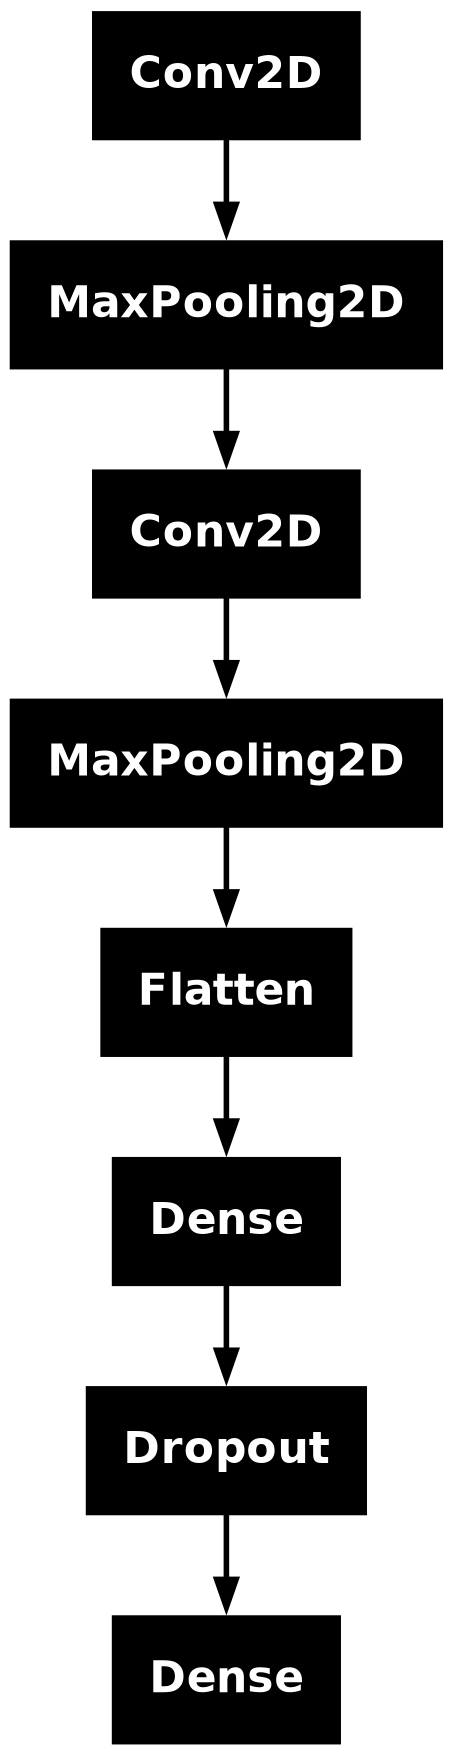

In [8]:
keras.utils.plot_model(model)

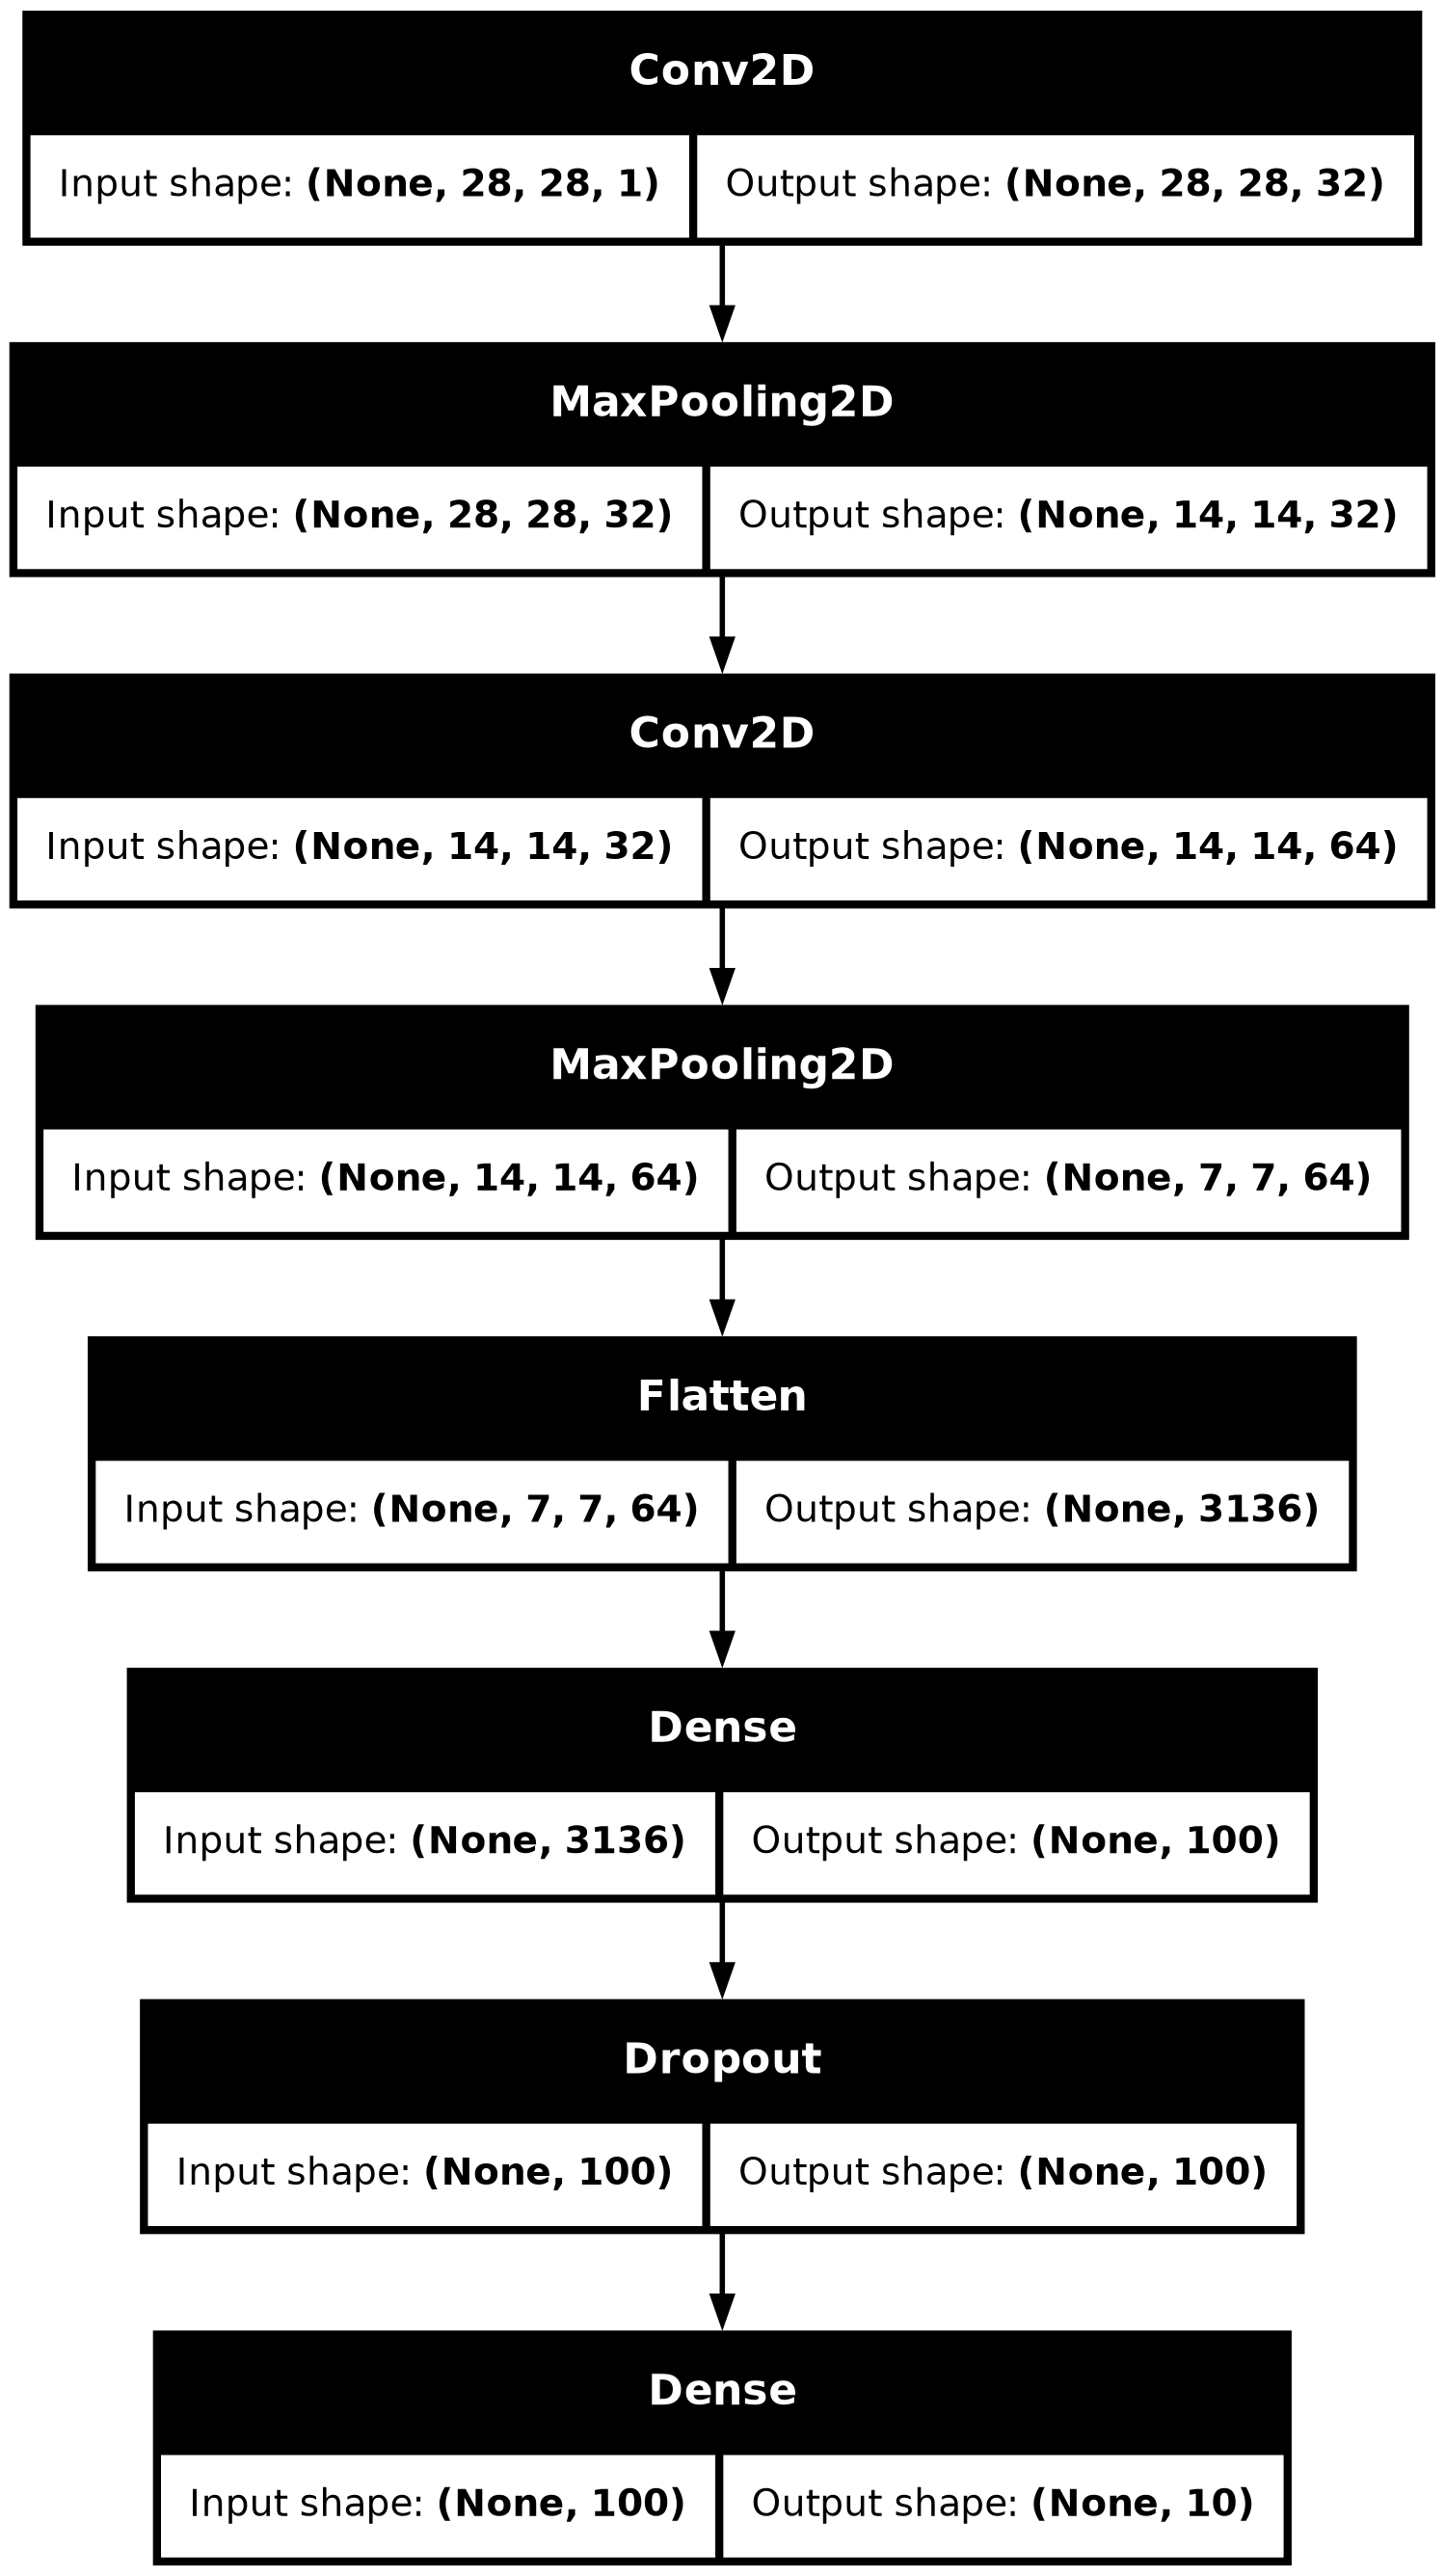

In [9]:
keras.utils.plot_model(model, show_shapes=True)

### 모델 컴파일 및 훈련

In [10]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics = ['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20


I0000 00:00:1763893900.062598  478699 cuda_dnn.cc:529] Loaded cuDNN version 91600


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7404 - loss: 0.7225 - val_accuracy: 0.8772 - val_loss: 0.3317
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8682 - loss: 0.3628 - val_accuracy: 0.8962 - val_loss: 0.2787
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8878 - loss: 0.3040 - val_accuracy: 0.9049 - val_loss: 0.2533
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9000 - loss: 0.2678 - val_accuracy: 0.9133 - val_loss: 0.2373
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9099 - loss: 0.2482 - val_accuracy: 0.9126 - val_loss: 0.2431
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9172 - loss: 0.2256 - val_accuracy: 0.9149 - val_loss: 0.2393


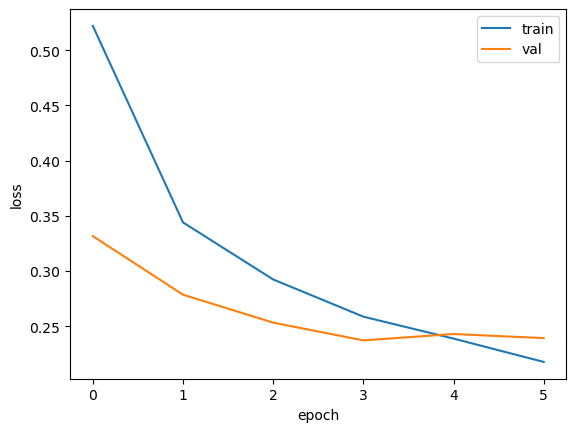

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [12]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9172 - loss: 0.2313


[0.2372663915157318, 0.9132500290870667]

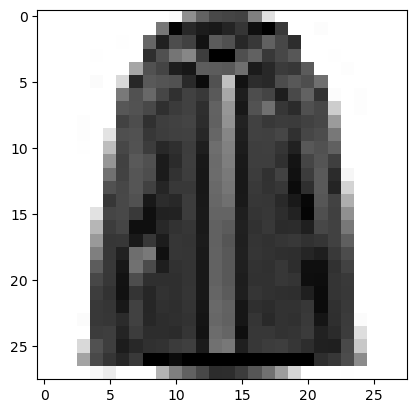

In [19]:
plt.imshow(val_scaled[8].reshape(28, 28), cmap='gray_r')
plt.show()

In [14]:
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
[[5.6535117e-15 8.4746673e-22 6.7393389e-17 1.3679732e-14 7.8526797e-17
  2.7399464e-15 1.9988673e-16 2.1415564e-13 1.0000000e+00 6.4976241e-16]]


2025-11-23 20:13:44.899376: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


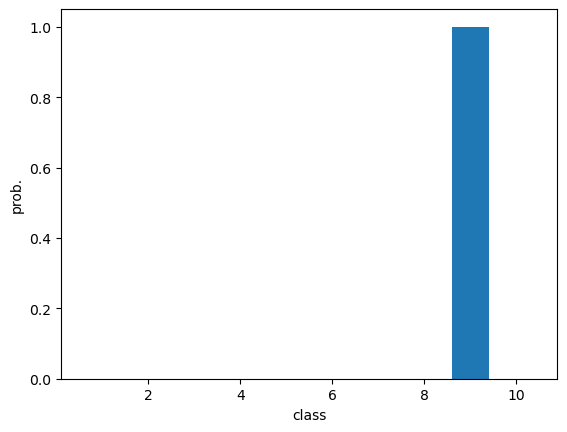

In [15]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [16]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']
import numpy as np
print(classes[np.argmax(preds)])
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

가방
  1/313 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.8750 - loss: 0.6092

2025-11-23 20:14:30.940151: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9058 - loss: 0.2652


[0.262926310300827, 0.9047999978065491]

## ch08-3 합성곱 신경망의 시각화

In [20]:
model = keras.models.load_model('./model/best-cnn-model.keras')

In [21]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [22]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [23]:
conv_weights = conv.weights[0].numpy()

print(conv_weights.mean(), conv_weights.std())

-0.017617775 0.22690606


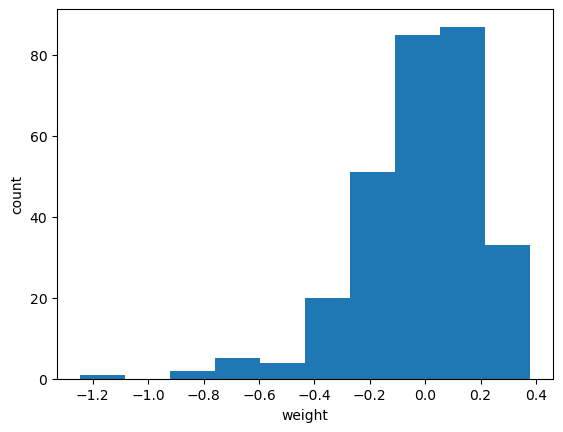

In [24]:
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

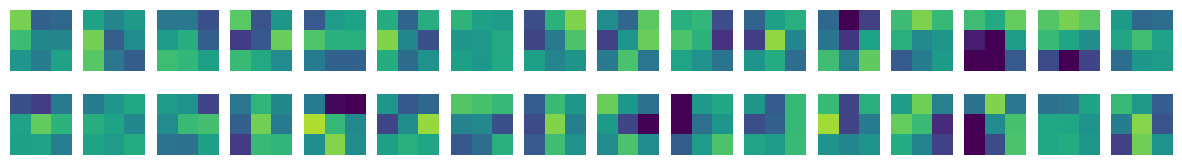

In [25]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [26]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28,28,1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                                          padding='same'))

In [27]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [28]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

0.0026544556 0.07910345


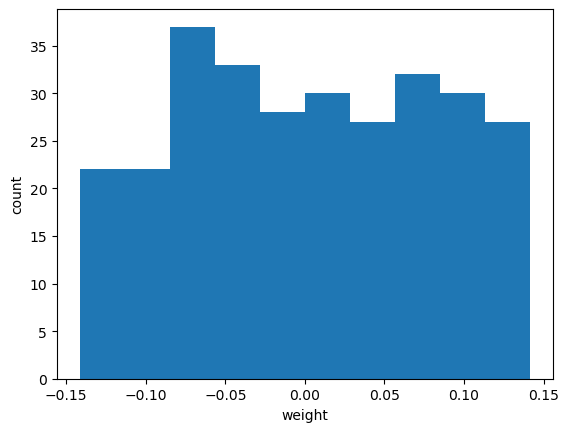

In [29]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

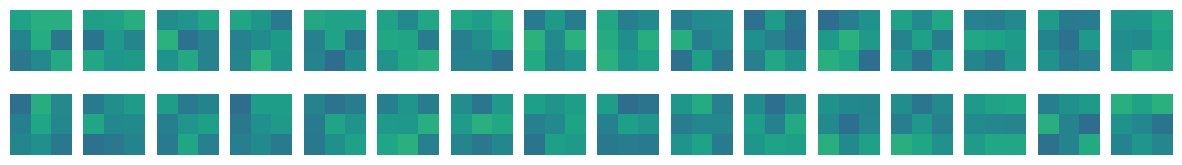

In [30]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

### 함수형 API

In [31]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

hidden = dense1(inputs)
outputs = dense2(hidden)

func_model = keras.Model(inputs, outputs)

In [32]:
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, name=input_layer>]


In [33]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

### 특성 맵 시각화

In [34]:
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

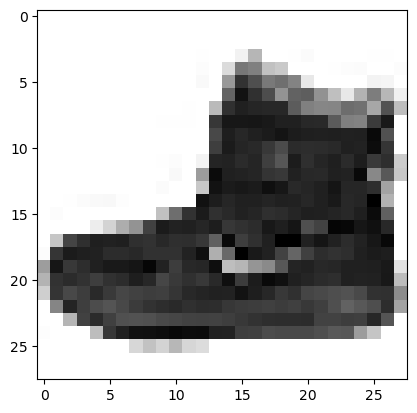

In [40]:
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [36]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1)/255.0
feature_maps = conv_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


2025-11-23 20:21:38.661644: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [37]:
print(feature_maps.shape)

(1, 28, 28, 32)


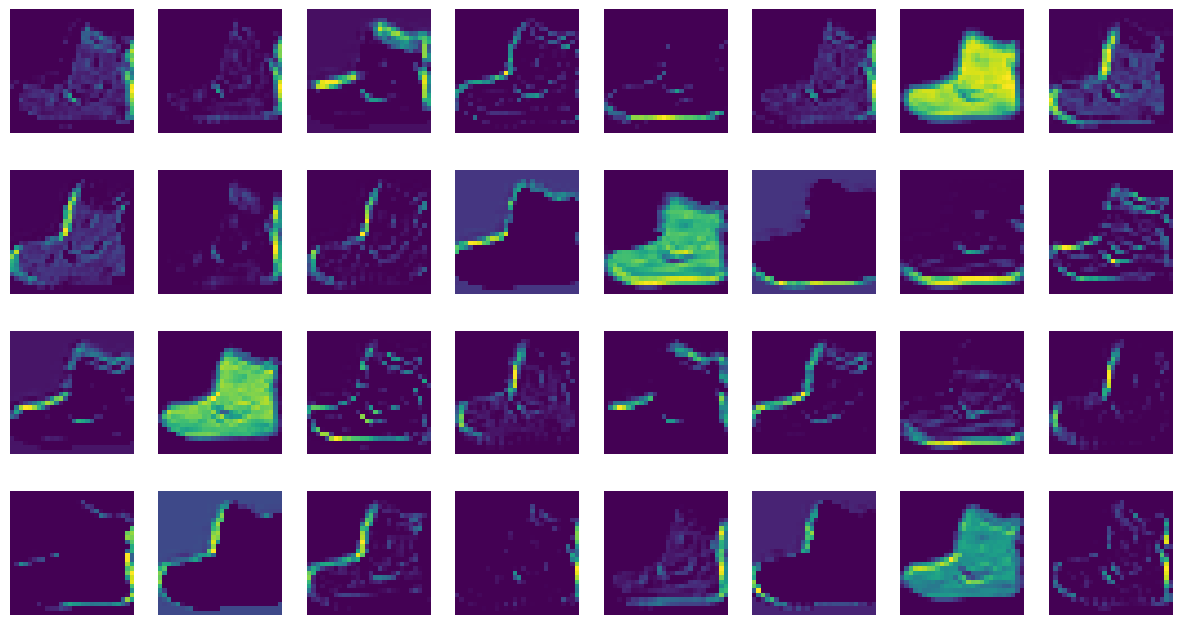

In [38]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()

In [41]:
conv2_acti = keras.Model(model.inputs, model.layers[2].output)

In [42]:
feature_maps = conv2_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


2025-11-23 20:22:29.655374: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
/home/user/miniforge3/envs/mldl_practice/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


In [43]:
print(feature_maps.shape)

(1, 14, 14, 64)


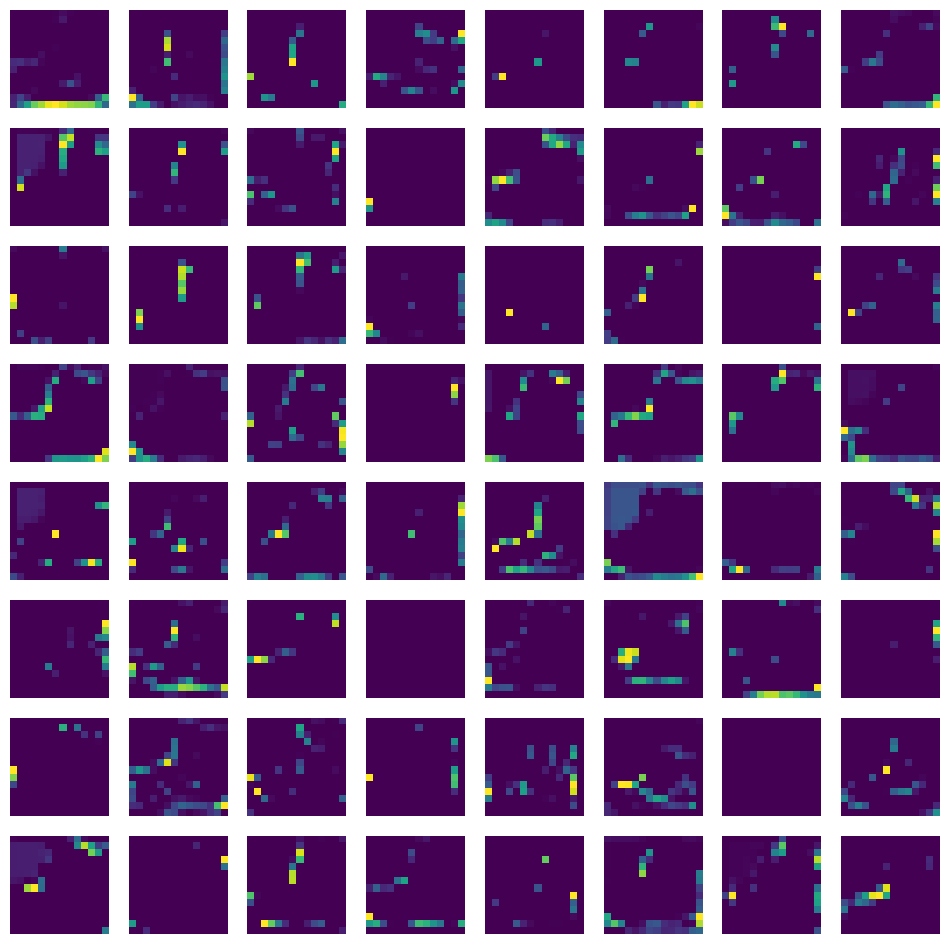

In [44]:
fig, axs = plt.subplots(8, 8, figsize=(12,12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()